# Notebook 19 - MATLAB Hough port and geofeature parity

Goal for this step:

1. Port and exercise MATLAB `weightedMedian.m`, `dohough.m`, and `hough_bin_pixels.m`.
2. Recheck MATLAB `geofeatures.alpha`, `phi`, and `faslen` parity.
3. Separate errors caused by the downstream formulas from errors caused by the image/mask/Hough stage.

Important distinction: the MATLAB `.mat` file stores Hough peak angles/weights (`alphas`, `ws`) but not the binary `fascicle_masked` image that entered `dohough`. So exact validation is possible for `weightedMedian` and the downstream formulas. The full Hough accumulator can only be tested diagnostically unless we also port MATLAB `filter_usimage.m` and regenerate the exact same fascicle mask.

In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib")

%load_ext autoreload
%autoreload 2

current = Path.cwd()
if (current / "ultrasound_tracker").exists():
    PROJECT_ROOT = current
elif (current.parent / "ultrasound_tracker").exists():
    PROJECT_ROOT = current.parent
else:
    raise FileNotFoundError("Could not find ultrasound_tracker folder")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)

PROJECT_ROOT = /Users/grosbedou/PycharmProjects/NDORMS


In [2]:
import json
import time

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ultrasound_tracker.legacy.frangi_detector import FrangiDetector
from ultrasound_tracker.matlab_compat import (
    compute_metrics,
    extract_geofeature_arrays,
    get_nested,
    load_matlab_result,
)
from ultrasound_tracker.timtrack_hough import DoHoughParams, dohough, weighted_median

plt.rcParams.update({
    "figure.figsize": (14, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
})

def sin_deg(x):
    return np.sin(np.deg2rad(x))

def metric_table(named_pairs):
    rows = []
    for name, ref, est in named_pairs:
        row = {"comparison": name}
        row.update(compute_metrics(ref, est))
        rows.append(row)
    return pd.DataFrame(rows)

def align(a, b):
    n = min(len(a), len(b))
    return np.asarray(a, dtype=float)[:n], np.asarray(b, dtype=float)[:n]

## Load MATLAB and Python outputs

The MATLAB geofeature arrays are the intermediate TimTrack values. These are the best targets before tuning the Kalman layer, because Kalman can hide upstream mismatches.

In [3]:
MATLAB_RESULT = PROJECT_ROOT / "data" / "matlab" / "slow_low_01_DOWN_tracked_Q=001.mat"
PY_TIMTRACK = PROJECT_ROOT / "results" / "timtrack_sequence_features_arrays.npz"
PY_UTT = PROJECT_ROOT / "results" / "ultratimtrack_geometric_kalman_features_arrays.npz"
VIDEO_PATH = PROJECT_ROOT / "data" / "raw" / "UltraTimTrack_test.mp4"
ROI_PATH = PROJECT_ROOT / "data" / "rois" / "UltraTimTrack_test_rois.json"
OUT_DIR = PROJECT_ROOT / "results" / "matlab_comparison"
OUT_DIR.mkdir(parents=True, exist_ok=True)

mat = load_matlab_result(MATLAB_RESULT)
matlab_geo = extract_geofeature_arrays(mat)
geofeature_entries = list(get_nested(mat, "Fdat.geofeatures"))
py_tim = dict(np.load(PY_TIMTRACK, allow_pickle=True))
py_utt = dict(np.load(PY_UTT, allow_pickle=True))

print("MATLAB geofeatures:", len(geofeature_entries))
print("Python TimTrack frames:", len(py_tim["frame"]))
print("Python UTT frames:", len(py_utt["frame"]))
print("MATLAB keys:", sorted(matlab_geo.keys()))
print("Python TimTrack keys:", sorted(py_tim.keys()))

MATLAB geofeatures: 2666
Python TimTrack frames: 2667
Python UTT frames: 2667
MATLAB keys: ['alpha_deg', 'brightness', 'deep_apo_angle_deg', 'deep_pos_y1', 'deep_pos_y2', 'extrapolated_fraction', 'faslen_px', 'muscle_thickness_px', 'phi_deg', 'super_apo_angle_deg', 'super_pos_y1', 'super_pos_y2']
Python TimTrack keys: ['deep_apo_angle_deg', 'deep_apo_lines', 'deep_attachments', 'fascicle_angle_deg', 'fascicle_length_px', 'fascicle_lines', 'fascicle_segments', 'frame', 'n_fascicle_candidates', 'pennation_angle_deg', 'success', 'sup_apo_lines', 'sup_attachments', 'time_s']


## Exact check: MATLAB saved peaks -> Python weighted median

MATLAB saved `geofeatures.alphas` and `geofeatures.ws`, which are the direct outputs of `dohough.m`. If the port of `weightedMedian.m` is correct, recomputing alpha from these saved arrays should reproduce MATLAB `geofeatures.alpha` exactly.

In [4]:
alpha_from_saved_peaks = np.asarray([
    weighted_median(np.asarray(entry["alphas"], dtype=float), np.asarray(entry["ws"], dtype=float))
    for entry in geofeature_entries
])

betha = matlab_geo["super_apo_angle_deg"]
thickness = matlab_geo["muscle_thickness_px"]
phi_from_saved_peaks = alpha_from_saved_peaks - betha
faslen_from_saved_peaks = thickness / sin_deg(phi_from_saved_peaks)

exact_metrics = metric_table([
    ("alpha: weightedMedian(saved alphas/ws)", matlab_geo["alpha_deg"], alpha_from_saved_peaks),
    ("phi: alpha - betha", matlab_geo["phi_deg"], phi_from_saved_peaks),
    ("faslen: thickness / sind(phi)", matlab_geo["faslen_px"], faslen_from_saved_peaks),
])
exact_metrics

,comparison,n,bias,mae,rmse,corr
0,alpha: weightedMedian(saved alphas/ws),2666,0.000000e+00,0.000000e+00,0.000000e+00,1.0
1,phi: alpha - betha,2666,0.000000e+00,0.000000e+00,0.000000e+00,1.0
2,faslen: thickness / sind(phi),2666,1.477588e-14,1.477588e-14,4.250979e-14,1.0


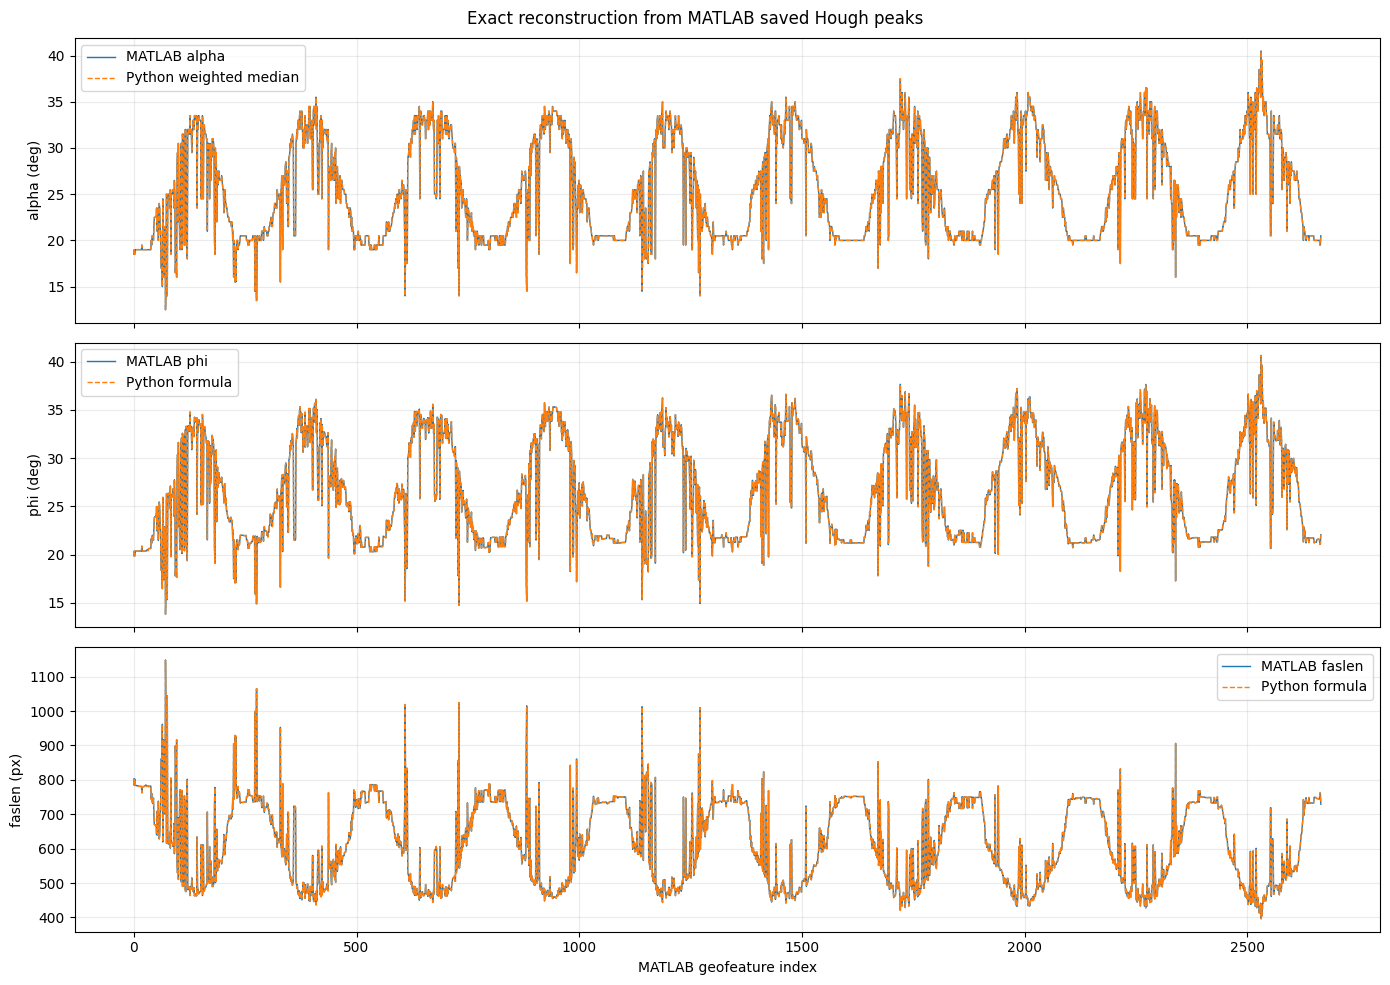

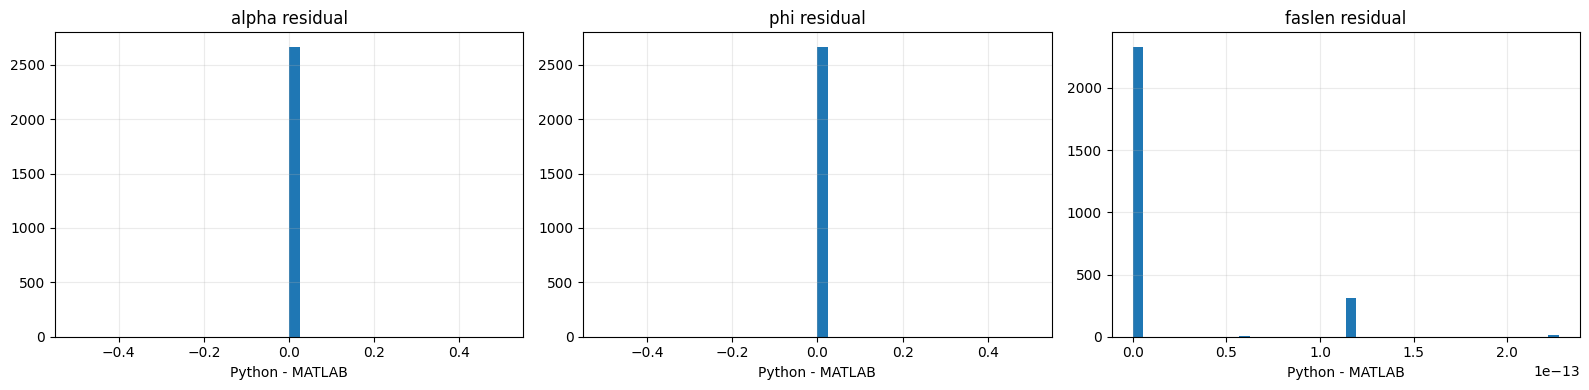

In [5]:
t = np.arange(len(alpha_from_saved_peaks))
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(t, matlab_geo["alpha_deg"], label="MATLAB alpha", linewidth=1.0)
axes[0].plot(t, alpha_from_saved_peaks, "--", label="Python weighted median", linewidth=1.0)
axes[0].set_ylabel("alpha (deg)")
axes[0].legend()

axes[1].plot(t, matlab_geo["phi_deg"], label="MATLAB phi", linewidth=1.0)
axes[1].plot(t, phi_from_saved_peaks, "--", label="Python formula", linewidth=1.0)
axes[1].set_ylabel("phi (deg)")
axes[1].legend()

axes[2].plot(t, matlab_geo["faslen_px"], label="MATLAB faslen", linewidth=1.0)
axes[2].plot(t, faslen_from_saved_peaks, "--", label="Python formula", linewidth=1.0)
axes[2].set_ylabel("faslen (px)")
axes[2].set_xlabel("MATLAB geofeature index")
axes[2].legend()

fig.suptitle("Exact reconstruction from MATLAB saved Hough peaks")
plt.tight_layout()
plt.show()

residuals = {
    "alpha residual": alpha_from_saved_peaks - matlab_geo["alpha_deg"],
    "phi residual": phi_from_saved_peaks - matlab_geo["phi_deg"],
    "faslen residual": faslen_from_saved_peaks - matlab_geo["faslen_px"],
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, residual) in zip(axes, residuals.items()):
    ax.hist(residual[np.isfinite(residual)], bins=40)
    ax.set_title(name)
    ax.set_xlabel("Python - MATLAB")
plt.tight_layout()
plt.show()

## Current Python TimTrack-like geofeature parity

This compares the existing Python TimTrack-like outputs against MATLAB `geofeatures`. Then it repeats the MATLAB formulas with Python alpha but MATLAB betha/thickness. That isolates how much of the `phi`/`faslen` mismatch is caused by alpha alone.

In [6]:
n = min(len(matlab_geo["alpha_deg"]), len(py_tim["fascicle_angle_deg"]))

matlab_alpha = matlab_geo["alpha_deg"][:n]
matlab_phi = matlab_geo["phi_deg"][:n]
matlab_faslen = matlab_geo["faslen_px"][:n]
matlab_betha = matlab_geo["super_apo_angle_deg"][:n]
matlab_thickness = matlab_geo["muscle_thickness_px"][:n]

py_alpha = np.asarray(py_tim["fascicle_angle_deg"], dtype=float)[:n]
py_phi = np.asarray(py_tim["pennation_angle_deg"], dtype=float)[:n]
py_faslen = np.asarray(py_tim["fascicle_length_px"], dtype=float)[:n]

phi_from_current_alpha_only = py_alpha - matlab_betha
faslen_from_current_alpha_only = matlab_thickness / sin_deg(phi_from_current_alpha_only)

current_metrics = metric_table([
    ("current Python alpha", matlab_alpha, py_alpha),
    ("current Python phi", matlab_phi, py_phi),
    ("current Python faslen", matlab_faslen, py_faslen),
    ("alpha-only phi with MATLAB betha", matlab_phi, phi_from_current_alpha_only),
    ("alpha-only faslen with MATLAB thickness", matlab_faslen, faslen_from_current_alpha_only),
])
current_metrics

,comparison,n,bias,mae,rmse,corr
0,current Python alpha,2666,-11.390793,11.659603,18.967960,-0.096262
1,current Python phi,2666,-10.682523,10.973685,18.415540,-0.083700
2,current Python faslen,2666,146.038386,155.143503,183.660677,0.373588
3,alpha-only phi with MATLAB betha,2666,-11.390793,11.659603,18.967960,-0.107641
4,alpha-only faslen with MATLAB thickness,2666,-37.909248,305.206226,507.329464,0.144595


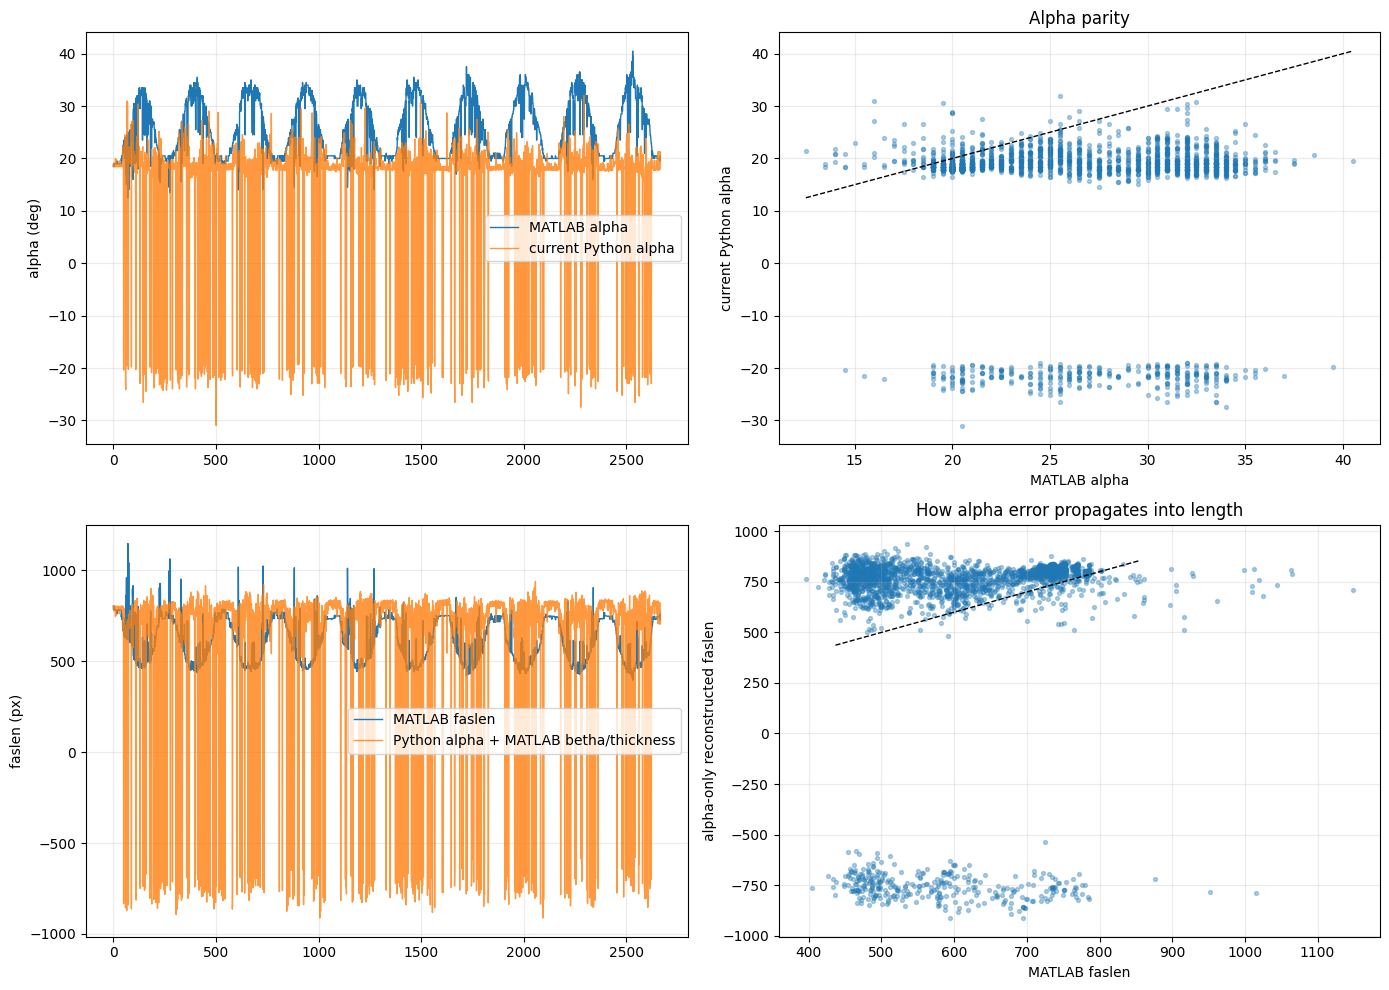

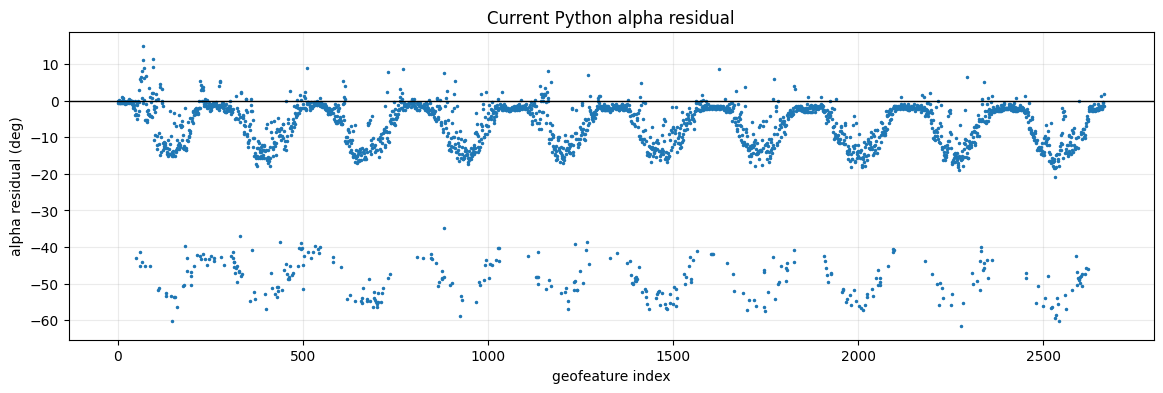

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(matlab_alpha, label="MATLAB alpha", linewidth=1)
axes[0, 0].plot(py_alpha, label="current Python alpha", linewidth=1, alpha=0.8)
axes[0, 0].set_ylabel("alpha (deg)")
axes[0, 0].legend()

axes[0, 1].scatter(matlab_alpha, py_alpha, s=8, alpha=0.35)
lim = [np.nanmin(matlab_alpha), np.nanmax(matlab_alpha)]
axes[0, 1].plot(lim, lim, "k--", linewidth=1)
axes[0, 1].set_xlabel("MATLAB alpha")
axes[0, 1].set_ylabel("current Python alpha")
axes[0, 1].set_title("Alpha parity")

axes[1, 0].plot(matlab_faslen, label="MATLAB faslen", linewidth=1)
axes[1, 0].plot(faslen_from_current_alpha_only, label="Python alpha + MATLAB betha/thickness", linewidth=1, alpha=0.8)
axes[1, 0].set_ylabel("faslen (px)")
axes[1, 0].legend()

axes[1, 1].scatter(matlab_faslen, faslen_from_current_alpha_only, s=8, alpha=0.35)
lo = np.nanpercentile(matlab_faslen, 1)
hi = np.nanpercentile(matlab_faslen, 99)
axes[1, 1].plot([lo, hi], [lo, hi], "k--", linewidth=1)
axes[1, 1].set_xlabel("MATLAB faslen")
axes[1, 1].set_ylabel("alpha-only reconstructed faslen")
axes[1, 1].set_title("How alpha error propagates into length")

plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(py_alpha - matlab_alpha, ".", markersize=3)
plt.axhline(0, color="k", linewidth=1)
plt.ylabel("alpha residual (deg)")
plt.xlabel("geofeature index")
plt.title("Current Python alpha residual")
plt.show()

## Diagnostic run: ported `dohough` on the current Python mask

This is not exact MATLAB parity yet, because the binary mask is generated by the current Python Frangi path and fascicle ROI. It is still useful: if this alpha is much closer than the current probabilistic-Hough/segment picker, then replacing the line-selection step helps. If it is still far, the next correction is the mask/preprocessing layer (`filter_usimage.m` and `get_fasMask.m`).

In [8]:
with ROI_PATH.open() as handle:
    rois = json.load(handle)

x, y, w, h = rois["fascicle"]
FRAME_STEP_FOR_HOUGH = 50
sample_indices = np.arange(0, n, FRAME_STEP_FOR_HOUGH, dtype=int)

fas_detector = FrangiDetector(
    sigmas=(1, 2, 4),
    alpha=0.5,
    beta=15.0,
    black_ridges=False,
    threshold=0.08,
    angle_min=10,
    angle_max=70,
    hough_threshold=15,
    min_line_length=25,
    max_line_gap=15,
)

hough_params = DoHoughParams(
    angle_range=(8.0, 80.0),
    thetares=1.0,
    rhores=1.0,
    emask_radius=(h / 2.0, w / 2.0),
    npeaks=10,
    replace_diagonal_bias=True,
)

print("Fascicle ROI:", rois["fascicle"])
print("Sampled frames:", len(sample_indices), "step:", FRAME_STEP_FOR_HOUGH)
print("Hough params:", hough_params)

Fascicle ROI: [17, 65, 686, 226]
Sampled frames: 54 step: 50
Hough params: DoHoughParams(houghangles='specified', angle_range=(8.0, 80.0), thetares=1.0, rhores=1.0, emask_radius=(113.0, 343.0), npeaks=10, show=False, replace_diagonal_bias=True)


In [9]:
def read_gray_frame(cap, frame_idx):
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_idx))
    ok, frame = cap.read()
    if not ok:
        return None
    if frame.ndim == 3:
        return cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    return frame.copy()

hough_alpha_sample = []
mask_density_sample = []
first_debug = None

cap = cv2.VideoCapture(str(VIDEO_PATH))
started = time.time()

for j, frame_idx in enumerate(sample_indices):
    gray = read_gray_frame(cap, int(frame_idx))
    if gray is None:
        hough_alpha_sample.append(np.nan)
        mask_density_sample.append(np.nan)
        continue

    crop = gray[y : y + h, x : x + w]
    vesselness = fas_detector.get_vesselness_map(crop)
    binary = vesselness >= fas_detector.threshold
    result = dohough(binary, hough_params)

    hough_alpha_sample.append(result["alpha"])
    mask_density_sample.append(float(np.mean(binary)))

    if first_debug is None:
        first_debug = {
            "frame_idx": int(frame_idx),
            "crop": crop,
            "vesselness": vesselness,
            "binary": binary,
            "result": result,
        }

cap.release()

hough_alpha_sample = np.asarray(hough_alpha_sample, dtype=float)
mask_density_sample = np.asarray(mask_density_sample, dtype=float)
elapsed = time.time() - started

print(f"Computed {len(sample_indices)} sampled Hough frames in {elapsed:.2f} s")
print("Finite Hough alpha:", np.sum(np.isfinite(hough_alpha_sample)), "/", len(hough_alpha_sample))

Computed 54 sampled Hough frames in 2.60 s
Finite Hough alpha: 54 / 54


In [10]:
matlab_alpha_sample = matlab_alpha[sample_indices]
matlab_phi_sample = matlab_phi[sample_indices]
matlab_faslen_sample = matlab_faslen[sample_indices]
matlab_betha_sample = matlab_betha[sample_indices]
matlab_thickness_sample = matlab_thickness[sample_indices]
py_alpha_sample = py_alpha[sample_indices]

phi_from_hough_alpha_only = hough_alpha_sample - matlab_betha_sample
faslen_from_hough_alpha_only = matlab_thickness_sample / sin_deg(phi_from_hough_alpha_only)

hough_sample_metrics = metric_table([
    ("ported dohough alpha on current mask", matlab_alpha_sample, hough_alpha_sample),
    ("current Python alpha on same sampled frames", matlab_alpha_sample, py_alpha_sample),
    ("ported alpha-only phi", matlab_phi_sample, phi_from_hough_alpha_only),
    ("ported alpha-only faslen", matlab_faslen_sample, faslen_from_hough_alpha_only),
])
hough_sample_metrics

,comparison,n,bias,mae,rmse,corr
0,ported dohough alpha on current mask,54,2.194444,2.435185,2.980647,0.920540
1,current Python alpha on same sampled frames,54,-13.355048,13.437569,21.655578,-0.162166
2,ported alpha-only phi,54,2.194444,2.435185,2.980647,0.914285
3,ported alpha-only faslen,54,-50.559168,54.477592,71.385429,0.915505


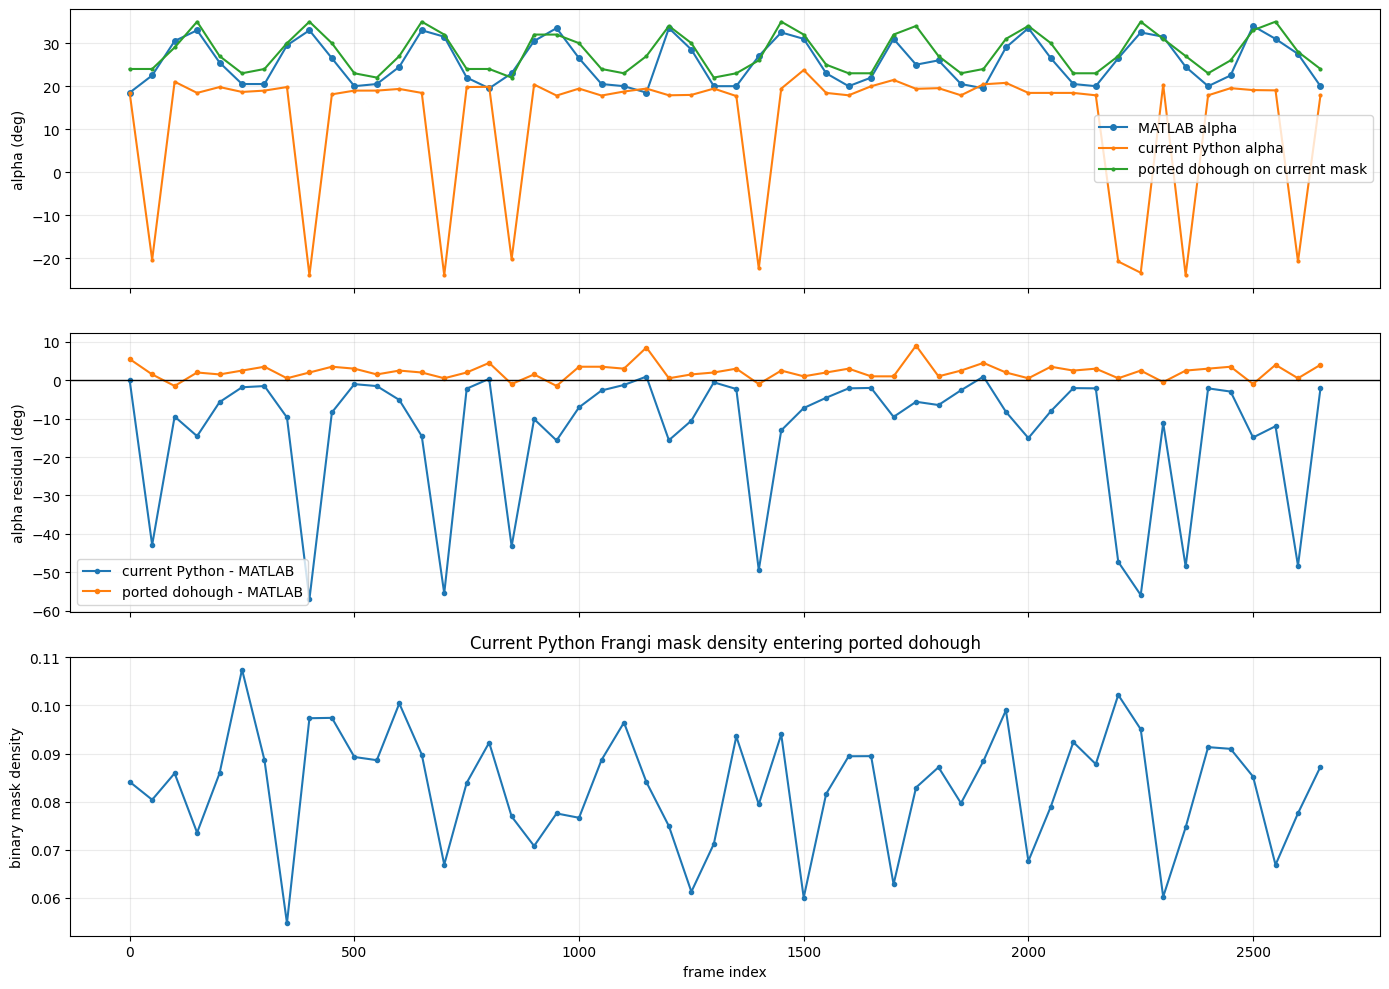

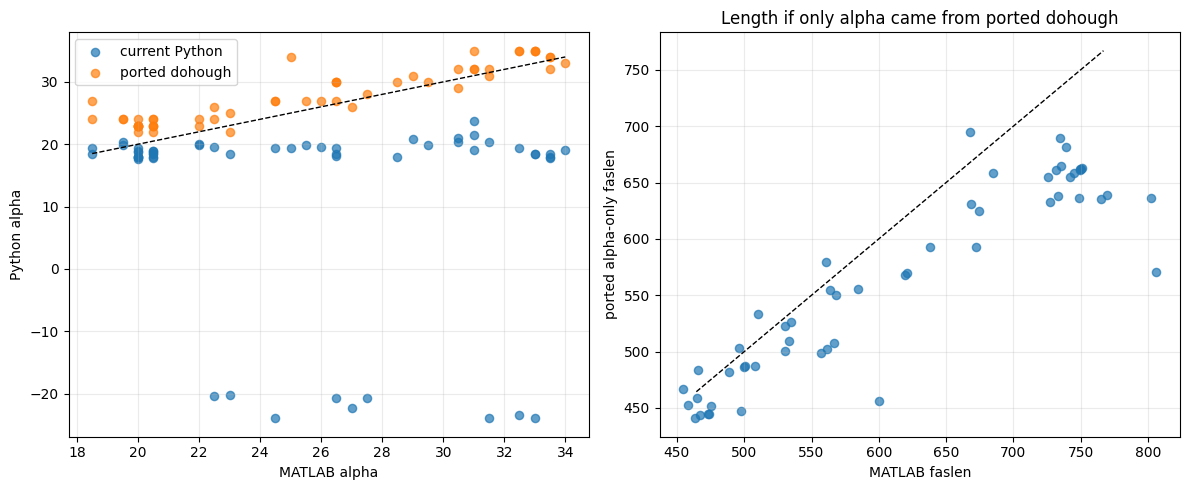

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(sample_indices, matlab_alpha_sample, "o-", label="MATLAB alpha", markersize=4)
axes[0].plot(sample_indices, py_alpha_sample, ".-", label="current Python alpha", markersize=4)
axes[0].plot(sample_indices, hough_alpha_sample, ".-", label="ported dohough on current mask", markersize=4)
axes[0].set_ylabel("alpha (deg)")
axes[0].legend()

axes[1].plot(sample_indices, py_alpha_sample - matlab_alpha_sample, ".-", label="current Python - MATLAB")
axes[1].plot(sample_indices, hough_alpha_sample - matlab_alpha_sample, ".-", label="ported dohough - MATLAB")
axes[1].axhline(0, color="k", linewidth=1)
axes[1].set_ylabel("alpha residual (deg)")
axes[1].legend()

axes[2].plot(sample_indices, mask_density_sample, ".-")
axes[2].set_ylabel("binary mask density")
axes[2].set_xlabel("frame index")
axes[2].set_title("Current Python Frangi mask density entering ported dohough")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(matlab_alpha_sample, py_alpha_sample, s=35, alpha=0.7, label="current Python")
axes[0].scatter(matlab_alpha_sample, hough_alpha_sample, s=35, alpha=0.7, label="ported dohough")
lo = np.nanmin(matlab_alpha_sample)
hi = np.nanmax(matlab_alpha_sample)
axes[0].plot([lo, hi], [lo, hi], "k--", linewidth=1)
axes[0].set_xlabel("MATLAB alpha")
axes[0].set_ylabel("Python alpha")
axes[0].legend()

axes[1].scatter(matlab_faslen_sample, faslen_from_hough_alpha_only, s=35, alpha=0.7)
lo = np.nanpercentile(matlab_faslen_sample, 5)
hi = np.nanpercentile(matlab_faslen_sample, 95)
axes[1].plot([lo, hi], [lo, hi], "k--", linewidth=1)
axes[1].set_xlabel("MATLAB faslen")
axes[1].set_ylabel("ported alpha-only faslen")
axes[1].set_title("Length if only alpha came from ported dohough")
plt.tight_layout()
plt.show()

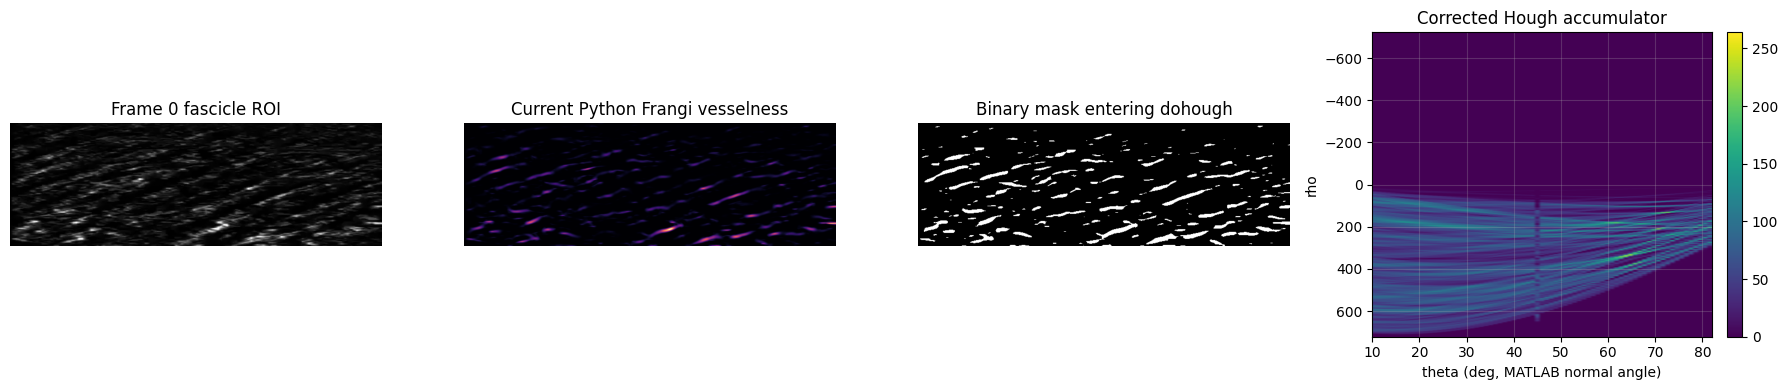

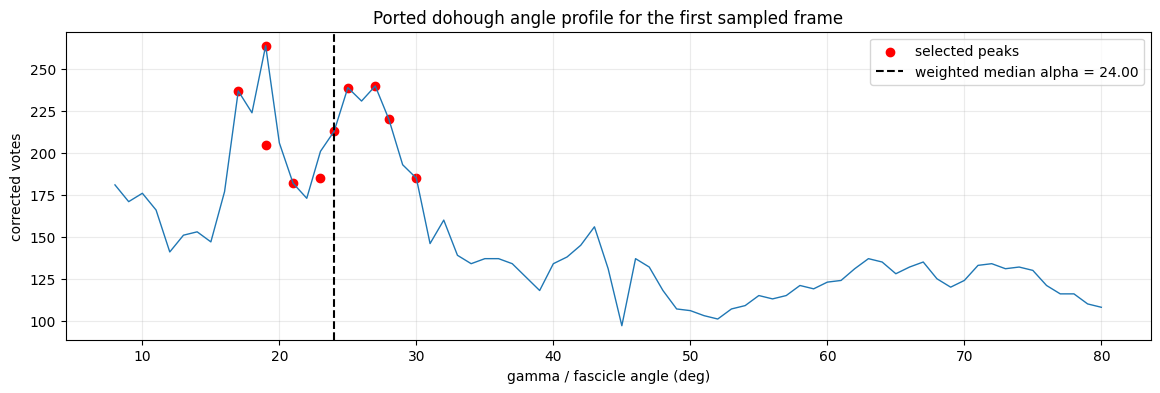

In [12]:
if first_debug is None:
    raise RuntimeError("No debug frame was collected")

debug = first_debug
result = debug["result"]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].imshow(debug["crop"], cmap="gray")
axes[0].set_title(f"Frame {debug['frame_idx']} fascicle ROI")
axes[0].axis("off")

axes[1].imshow(debug["vesselness"], cmap="magma")
axes[1].set_title("Current Python Frangi vesselness")
axes[1].axis("off")

axes[2].imshow(debug["binary"], cmap="gray")
axes[2].set_title("Binary mask entering dohough")
axes[2].axis("off")

im = axes[3].imshow(
    result["hmat_corrected"],
    aspect="auto",
    cmap="viridis",
    extent=[result["theta"][0], result["theta"][-1], result["rho"][-1], result["rho"][0]],
)
axes[3].set_xlabel("theta (deg, MATLAB normal angle)")
axes[3].set_ylabel("rho")
axes[3].set_title("Corrected Hough accumulator")
plt.colorbar(im, ax=axes[3], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(result["gamma"], result["h_by_angle"], linewidth=1)
plt.scatter(result["alphas"], result["weights"], color="red", label="selected peaks")
plt.axvline(result["alpha"], color="black", linestyle="--", label=f"weighted median alpha = {result['alpha']:.2f}")
plt.xlabel("gamma / fascicle angle (deg)")
plt.ylabel("corrected votes")
plt.title("Ported dohough angle profile for the first sampled frame")
plt.legend()
plt.show()

## Interim interpretation

The exact reconstruction above answers a narrow but important question: the weighted median and the downstream `alpha -> phi -> faslen` formulas are now compatible with MATLAB.

The sampled Hough run answers a different question: what happens if the MATLAB-style Hough/weighted-median logic is applied to the current Python mask. If the sampled Hough alpha still disagrees with MATLAB, the next discrepancy is upstream of `dohough`: the binary mask produced by `filter_usimage.m`, the aponeurosis subtraction, and the ellipse mask from `get_fasMask.m`.

In [13]:
exact_metrics_out = exact_metrics.copy()
current_metrics_out = current_metrics.copy()
hough_sample_metrics_out = hough_sample_metrics.copy()

exact_metrics_out.to_csv(OUT_DIR / "notebook19_exact_geofeature_reconstruction_metrics.csv", index=False)
current_metrics_out.to_csv(OUT_DIR / "notebook19_current_python_geofeature_metrics.csv", index=False)
hough_sample_metrics_out.to_csv(OUT_DIR / "notebook19_ported_hough_sample_metrics.csv", index=False)

np.savez(
    OUT_DIR / "notebook19_ported_hough_sample_arrays.npz",
    sample_indices=sample_indices,
    matlab_alpha_sample=matlab_alpha_sample,
    current_python_alpha_sample=py_alpha_sample,
    ported_hough_alpha_sample=hough_alpha_sample,
    mask_density_sample=mask_density_sample,
    phi_from_hough_alpha_only=phi_from_hough_alpha_only,
    faslen_from_hough_alpha_only=faslen_from_hough_alpha_only,
)

print("Saved:")
print(" -", OUT_DIR / "notebook19_exact_geofeature_reconstruction_metrics.csv")
print(" -", OUT_DIR / "notebook19_current_python_geofeature_metrics.csv")
print(" -", OUT_DIR / "notebook19_ported_hough_sample_metrics.csv")
print(" -", OUT_DIR / "notebook19_ported_hough_sample_arrays.npz")

Saved:
 - /Users/grosbedou/PycharmProjects/NDORMS/results/matlab_comparison/notebook19_exact_geofeature_reconstruction_metrics.csv
 - /Users/grosbedou/PycharmProjects/NDORMS/results/matlab_comparison/notebook19_current_python_geofeature_metrics.csv
 - /Users/grosbedou/PycharmProjects/NDORMS/results/matlab_comparison/notebook19_ported_hough_sample_metrics.csv
 - /Users/grosbedou/PycharmProjects/NDORMS/results/matlab_comparison/notebook19_ported_hough_sample_arrays.npz


here my alpha is segment-based and sign-sensitive. Will change in next notebook